# Exploratory and Geospatial Analysis of Artisanal Mining Sites in the DRC

The latest 2023 Cobalt Market Report noted that 73% of cobalt demand is being driven by battery applications. As the world slowly embraces a transition to clean energy, 96% of the 2023 demand growth was due to electric vehicle (EV) production, followed by portable electronics and energy storage, as cobalt remains a necessary component of lithium-ion batteries. As demand increases due to cobalt's potential increase to battery life and energy intensity, the supply chain is seeing increased pressure and urgent efforts to address the persistent human rights violations are more important than ever. Additionally, research and development and investment is needed to reduce cobalt in lithium-ion batteries and cobalt-free battery alternatives that are economically viable and safe. Such alternatives have already started to be explored including organic cathode materials developed by MIT chemists and lithium-iron phosphate batteries already in use in some of Tesla's newer vehicles. 

The Democratic Republic of the Congo (DRC) mines 2/3's of the global cobalt supply and has the world's largest reserve. Below I will explore open data from artisinal mining sites in the Eastern DRC made available by the International Peace Information Service (IPIS). IPIS is an independent research institute with a mission to realize a vision of durable peace, sustainable development and the fulfilment of human rights. The focus is on highlighting the hazardous working conditions and environmental disruption to surrounding protected natural areas.

In [65]:
import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

# Import required python packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Read the mining data, we will utilize the GeoJSON file from https://geo.ipisresearch.be/geoserver/web/wicket/bookmarkable/org.geoserver.web.demo.MapPreviewPage?0
drc_mining_sites = gpd.read_file("http://geo.ipisresearch.be/geoserver/public/ows?service=WFS&version=1.0.0&request=GetFeature&typeName=public:cod_mines_curated_all_opendata_p_ipis&outputFormat=application%2Fjson")

In [6]:
# Print the first few rows and Coordinate Reference System (CRS)
print(drc_mining_sites.columns.values)
print(drc_mining_sites.crs)
print(len(drc_mining_sites))

['vid' 'cid' 'id' 'source' 'project' 'pcode' 'name' 'visit_date'
 'visit_onsite' 'visit_onsite_novisitreason' 'longitude' 'latitude'
 'location_origin' 'province' 'province_old' 'territoire' 'collectivite'
 'groupement' 'village' 'workers_numb' 'access_dry' 'access_wet'
 'is_3t_mine' 'is_gold_mine' 'mineral1' 'selling_points_mineral1'
 'final_destination_mineral1' 'mineral2' 'selling_points_mineral2'
 'final_destination_mineral2' 'mineral3' 'selling_points_mineral3'
 'final_destination_mineral3' 'mercury' 'presence' 'interference'
 'armed_group1' 'type_armed_group1' 'frequency_armed_group1'
 'taxation_armed_group1' 'commerce_taxation_armed_group1'
 'entrance_taxation_armed_group1' 'monopoly_armed_group1'
 'buying_minerals_armed_group1' 'digging_armed_group1'
 'forced_labour_armed_group1' 'pillaging_armed_group1'
 'pit_ownership_armed_group1' 'armed_group2' 'type_armed_group2'
 'frequency_armed_group2' 'taxation_armed_group2'
 'commerce_taxation_armed_group2' 'entrance_taxation_armed_gr

# Cleaning the data

In [7]:
# Replace empty strings with np.nan
drc_mining_sites['workers_numb'].replace('', np.nan, inplace=True)

# Drop rows where there are no workers listed
drc_mining_sites.dropna(subset=['workers_numb'], inplace=True)
#drc_mining_sites.loc[drc_mining_sites['workers_numb'] != 0]
print(drc_mining_sites.info)

<bound method DataFrame.info of        vid   cid   id                      source        project  \
0        1     1    1  IPIS - Ministère des Mines    IPIS - 2009   
1        2     2    2  IPIS - Ministère des Mines    IPIS - 2009   
5        6     6    6  IPIS - Ministère des Mines    IPIS - 2009   
6        7     7    7  IPIS - Ministère des Mines    IPIS - 2009   
7        8     8    8  IPIS - Ministère des Mines    IPIS - 2009   
...    ...   ...  ...                         ...            ...   
6948  6949  5320  969                        IPIS  IPIS - Madini   
6949  6950  5321  970                        IPIS  IPIS - Madini   
6950  6951  5322  971                        IPIS  IPIS - Madini   
6951  6952  5323  972                        IPIS  IPIS - Madini   
6952  6953  5324  973                        IPIS  IPIS - Madini   

             pcode        name  visit_date  visit_onsite  \
0     codmine00191        Eohe  2009-01-01             1   
1     codmine00192        Eita 

In [8]:
# We can narrow down the list of the minerals with the most mines in the DRC
# The minerals are an object, let's first convert to a category. We're only going to be using the main mineral in the mineral1 column
drc_mining_sites["mineral1"] = drc_mining_sites["mineral1"].astype("category")
#print(drc_mining_sites["mineral1"].cat.categories)

#Let's see the total occurances for each mineral category
drc_mining_sites['mineral1'].value_counts()

mineral1
Or                                      3636
Cassitérite                             1285
Coltan                                   292
Cuivre                                   109
Wolframite                                76
Diamant                                   74
Cobalt                                    27
Tourmaline                                14
Manganèse                                  2
Améthyste                                  1
Manvenve                                   1
Minerais mixtes (Cassitérite/Coltan)       1
Monazite                                   1
Pyrochlore                                 1
Saphir                                     1
Name: count, dtype: int64

In [9]:
# A few of the minerals only have one existing mine in the Congo, let's narrrow down by number of mines and group all others under a category of 'Other'
# First let's drop any null values in the minerals column
drc_mining_sites.dropna(subset=["mineral1"], inplace=True)

# Create a mapping to group less prevalent minerals as 'Other'
mineral_mapping = {
    'Améthyste': "Other",
    'Manvenve': "Other",
    'Manganèse': "Other",
    'Minerais mixtes (Cassitérite/Coltan)': "Other",
    'Monazite': "Other",
    'Pyrochlore': "Other",
    'Saphir': "Other",
    'Tourmaline': "Other",
    'inconnu': "Other"
}

# Create a new column with the new 'Other' category and the ones we want to focus on
drc_mining_sites["grouped_minerals"] = drc_mining_sites["mineral1"].map(mineral_mapping).fillna(drc_mining_sites["mineral1"])

# Now let's get the new count per category
drc_mining_sites['grouped_minerals'].value_counts()

grouped_minerals
Or             3636
Cassitérite    1285
Coltan          292
Cuivre          109
Wolframite       76
Diamant          74
Cobalt           27
Other            22
Name: count, dtype: int64

In [10]:
# Translate certain category names from French to English
drc_mining_sites['grouped_minerals'] = drc_mining_sites['grouped_minerals'].replace({'Or': 'Gold', 'Cassitérite': 'Cassiterite', 'Cuivre': 'Copper', 'Diamant': 'Diamond'})

# Test translations
drc_mining_sites['grouped_minerals'].value_counts()

grouped_minerals
Gold           3636
Cassiterite    1285
Coltan          292
Copper          109
Wolframite       76
Diamond          74
Cobalt           27
Other            22
Name: count, dtype: int64

# Exploratory Data Analysis
## Mining sites visits and amount of workers per province
Let's determine how many mining sites were visited by province, how many of those were unique (considering mines can be revisited many times) and how many workers there are in the dataset.

Number of unique mines: 2986
5521
333
333


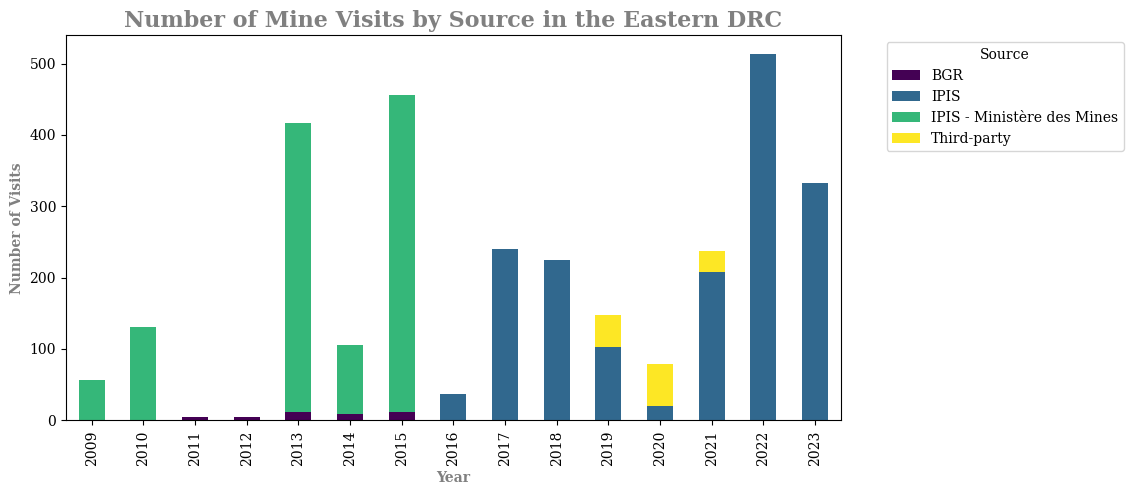

In [11]:
# How many unique mines are there?
unique_mines = drc_mining_sites['pcode'].value_counts().count()
print(f"Number of unique mines: {unique_mines}")

# How many visits does this dataset contain? Simply counting the number of lines
drc_mining_sites['total_visits'] = len(drc_mining_sites)
print(len(drc_mining_sites))

# How many visits were made in 2023?
drc_mining_sites['visit_date'] = pd.to_datetime(drc_mining_sites['visit_date'])
count_visits_2023 = drc_mining_sites[drc_mining_sites['visit_date'].dt.strftime('%Y-%m-%d').between('2023-01-01', '2023-12-31')]
print(len(count_visits_2023))

# Create a subset of the data keeping only uniques mines visited and the last visit (considering mines can be revisited multiple times)
unique_mines_visited = drc_mining_sites.sort_values('visit_date').groupby('pcode').tail(1)

# Set a few rcParams for visualizations
plt.rcParams['font.family'] = 'serif'  # Set the font family to 'serif'
plt.rcParams['font.size'] = 10  # Set the font size to 10

# How many visits were carried out per year and by what source?
unique_mines_visited['visit_date'] = pd.to_datetime(unique_mines_visited['visit_date'])
count_unique_visits_2023 = unique_mines_visited[unique_mines_visited['visit_date'].dt.strftime('%Y-%m-%d').between('2023-01-01', '2023-12-31')]
print(len(count_unique_visits_2023))


unique_mines_visited['visit_year'] = unique_mines_visited['visit_date'].dt.year
projects_per_year = unique_mines_visited.groupby(['visit_year', 'source']).size().unstack(fill_value=0)
projects_per_year.plot(kind='bar', stacked=True, figsize=(10,5), cmap="viridis")
plt.xlabel("Year", fontweight="bold", color="Gray")
plt.ylabel("Number of Visits", fontweight="bold", color="Gray")
plt.title("Number of Mine Visits by Source in the Eastern DRC", fontsize=16, fontweight="bold", color="Gray")
plt.legend(title="Source", bbox_to_anchor=(1.05, 1))
plt.show()


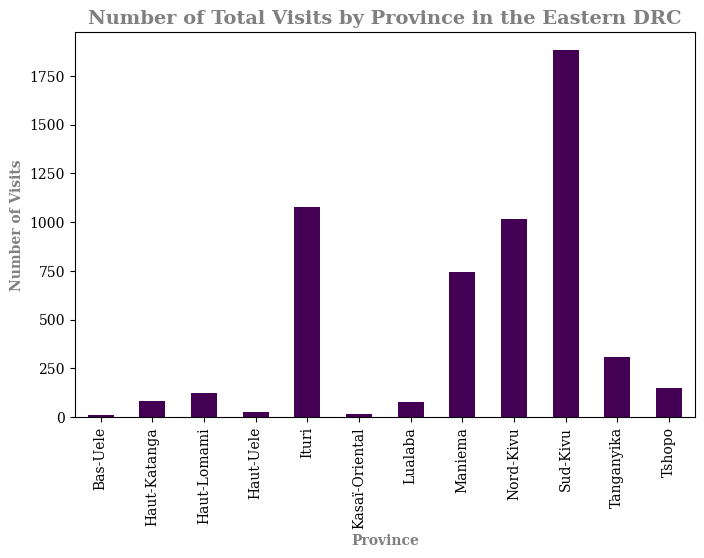

In [12]:
# Determine how many total times mining sites were visited by province
visits_per_province = drc_mining_sites.groupby('province')['total_visits'].count()
visits_per_province.plot(kind='bar', figsize=(8,5), cmap="viridis")
plt.xlabel("Province", fontweight="bold", color="Gray")
plt.ylabel("Number of Visits", fontweight="bold", color="Gray")
plt.title("Number of Total Visits by Province in the Eastern DRC",  fontsize=14, fontweight="bold", color="Gray")
plt.show()

In [15]:
# How many mines are there per province
mines_per_province = unique_mines_visited.groupby('province')['pcode'].count()
print(mines_per_province)

# Sum number of workers, while grouping by province in descending order
workers_per_province = unique_mines_visited.groupby('province')['workers_numb'].sum().sort_values(ascending=False)
print(workers_per_province.sum())

province
Bas-Uele           12
Haut-Katanga       69
Haut-Lomami        79
Haut-Uele          28
Ituri             457
Kasaï-Oriental     15
Lualaba            66
Maniema           465
Nord-Kivu         697
Sud-Kivu          804
Tanganyika        181
Tshopo            113
Name: pcode, dtype: int64
467491.0


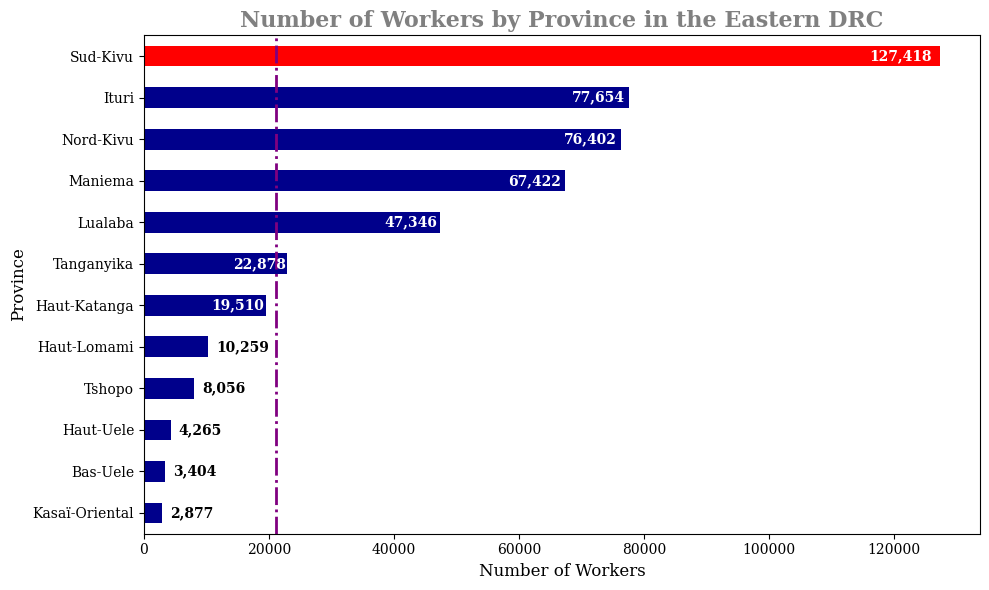

In [16]:
# Identify the province with the most workers
highlight_color = "red"  # Color for the province with the most workers
default_color = "darkblue"  # Color for the rest
colors = [highlight_color if i == 0 else default_color for i in range(len(workers_per_province))]

# Plot horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))
workers_per_province.plot(
    kind='barh', 
    color=colors, 
    figsize=(10, 6), 
    ax=ax
)

# Customize labels and title
plt.xlabel("Number of Workers", fontsize=12)
plt.ylabel("Province", fontsize=12)
plt.title("Number of Workers by Province in the Eastern DRC", fontsize=16, fontweight="bold", color="gray")

# Calculate median
median_value = workers_per_province.median()

# Add overlay line for the median
ax.axvline(median_value, color='purple', linestyle='-.', linewidth=2, label=f"Median: {median_value:,}")

# Add label for the median
#ax.text(median_value, -0.5, f"Median: {int(median_value):,}", fontsize=10, color='purple', ha='center')

# Add text annotations dynamically: inside for large bars, outside for small bars
for i, (value, label) in enumerate(zip(workers_per_province, workers_per_province.index)):
    if value > workers_per_province.max() * 0.15:  # Threshold: 15% of the max value
        # Place annotation inside the bar
        x_position = value - (value * 0.01)  # Slight offset inward
        ha = 'right'  # Align text to the right
        color = "white"  # Use contrasting color for visibility
    else:
        # Place annotation outside the bar
        x_position = value + (workers_per_province.max() * 0.01)  # Slight offset outward
        ha = 'left'  # Align text to the left
        color = "black"  # Default text color

    # Add annotation
    ax.text(x_position, i, f"{int(value):,}", va='center', ha=ha, fontsize=10, fontweight= "bold", color=color)

plt.gca().invert_yaxis()  # Invert y-axis to show the largest on top
plt.tight_layout()
plt.show()

In [17]:
# Calculate total workers across all provinces
total_workers = unique_mines_visited['workers_numb'].sum()

# Group by province and calculate aggregated stats
province_stats = unique_mines_visited.groupby('grouped_minerals')['workers_numb'].agg(
    total_workers='sum',  # Total workers per province
    max_workers='max',    # Max workers in a mine
    min_workers='min',    # Min workers in a mine
    median_workers='median',  # Median workers in a mine
    avg_workers='mean'    # Average workers in a mine
)

# Add a column for proportion of total workers
province_stats['worker_proportion'] = province_stats['total_workers'] / total_workers

# Print the results
print("Aggregated Stats by Province:")
print(province_stats.sort_values('worker_proportion', ascending=False))


Aggregated Stats by Province:
                  total_workers  max_workers  min_workers  median_workers  \
grouped_minerals                                                            
Gold                   294181.0       6200.0          0.0            60.0   
Cassiterite             84750.0       2500.0          0.0            70.0   
Copper                  55922.0      10700.0          0.0           120.0   
Coltan                  11965.0       2000.0          0.0            40.0   
Diamond                 11689.0       2000.0          0.0            53.0   
Cobalt                   4055.0        800.0         20.0           100.0   
Wolframite               3339.0       2000.0          0.0            20.0   
Other                    1590.0        873.0          0.0            10.0   

                  avg_workers  worker_proportion  
grouped_minerals                                  
Gold               149.330457           0.629276  
Cassiterite        130.989181           0.1812

## Worker exposure to interference by armed groups
Sud-Kivu had the most mine visits out of all the other provinces in the eastern DRC. As per IPIS documentation, the information collected at the last IPIS visit can be considered as complete and as the most recent one. Let's use our unique_mines_visited subset that we created in the previous exercise and take into account only the information from the last IPIS visit to determine the amount of workers exposed to interference by armed group.

In [18]:
# How many of their sites engage in illegal taxation?
illegal_taxation_count = unique_mines_visited.groupby('armed_group1')['taxation_armed_group1'].sum()
illegal_taxation = illegal_taxation_count.sort_values(ascending=False)
print(illegal_taxation)

# What is the precentage of their total sites engaged in illegal taxation
armed_group_sites = unique_mines_visited['armed_group1'].value_counts()
percentage_illegal = (illegal_taxation_count / armed_group_sites) * 100
print(percentage_illegal)

armed_group1
FARDC                                     531.0
Raïa Mutomboki                             55.0
NDC-Rénové                                 43.0
NDC                                        38.0
Maï-Maï Simba (ex-Morgan - Mangaribi)      26.0
Maï-Maï FPP/AP                             25.0
FDLR                                       16.0
Maï-Maï UPLD                               13.0
FABB (Forces Armées Biloze Bishambuki)     10.0
Police des Mines (PMH)                     10.0
Maï-Maï Yakutumba                           8.0
Maï-Maï Simba                               8.0
Maï-Maï Ebuela Mutetezi                     6.0
Jeunesse Autodéfense Zaïre                  6.0
FRPI                                        5.0
Ngomino                                     5.0
Maï-Maï Lwesula                             5.0
UPLC                                        4.0
Maï-Maï Juvenal                             4.0
Maï-Maï Luc                                 3.0
Maï-Maï Kifuafua           

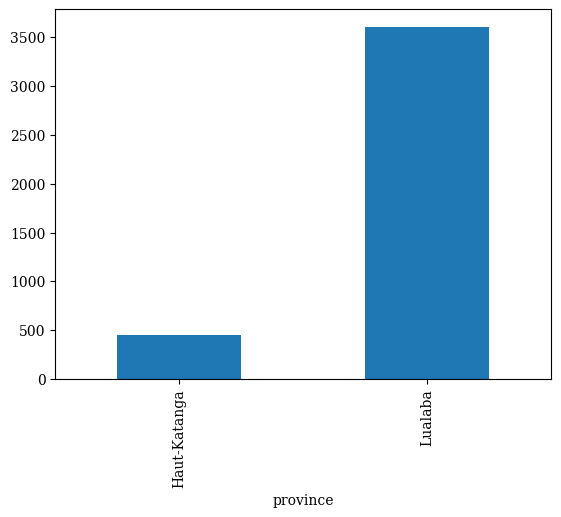

0.0 cobalt mines have interference from armed groups
province
Nord-Kivu     0.336073
Sud-Kivu      0.318721
Ituri         0.165297
Maniema       0.075799
Tshopo        0.052055
Tanganyika    0.050228
Haut-Uele     0.001826
Name: proportion, dtype: float64


In [22]:
# In which provinces are the cobalt mines located?
cobalt_mines = unique_mines_visited[unique_mines_visited['grouped_minerals'] == 'Cobalt']
cobalt_stats_per_province = cobalt_mines.groupby('province')['workers_numb'].sum()
cobalt_stats_per_province.plot(kind='bar')
plt.show()

# A majority of cobalt mines are located in the Lualaba province. Do cobalt mines have interference from armed groups?
cobalt_interference = cobalt_mines['interference'].sum()
print(cobalt_interference, "cobalt mines have interference from armed groups")

# Since cobalt mines don't suffer from interference from armed groups, let's take a look at which provinces have the highest proportion of mines with interference?
interference_exists = unique_mines_visited[unique_mines_visited['interference'] == 1]
province_interference = interference_exists['province'].value_counts(normalize=True, sort=True)
print(province_interference)

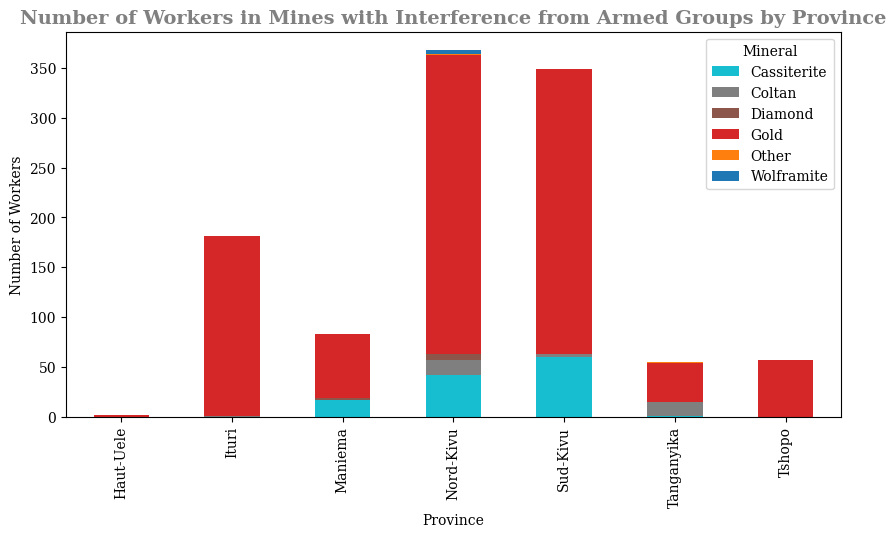

In [23]:
# Nord-Kivu and South-Kivu both have around ~30% of mines with interference from armed groups. How many workers work at mines in the Eastern DRC with interference from armed groups?
workers_interference = interference_exists.groupby(['province', 'grouped_minerals'])['workers_numb'].size().unstack(fill_value=0)
workers_interference.plot(kind='bar', stacked=True, figsize=(10,5), cmap="tab10_r")
plt.xlabel("Province")
plt.ylabel("Number of Workers")
plt.title("Number of Workers in Mines with Interference from Armed Groups by Province", fontsize=14, fontweight="bold", color="gray")
plt.legend(title="Mineral", bbox_to_anchor=(1, 1))
plt.show()

In [24]:
# Which are the main armed groups measured by how many workers work at mines where they operate? 
armed_groups_count_by_worker = unique_mines_visited.groupby('armed_group1')['workers_numb'].sum()
armed_groups_sorted = armed_groups_count_by_worker.sort_values(ascending=False)
print(armed_groups_sorted)

# How many of their sites engage in illegal taxation?
illegal_taxation_count = unique_mines_visited.groupby('armed_group1')['taxation_armed_group1'].sum()
illegal_taxation = illegal_taxation_count.sort_values(ascending=False)
print(illegal_taxation)

# What is the precentage of their total sites engaged in illegal taxation
armed_group_sites = unique_mines_visited['armed_group1'].value_counts()
percentage_illegal = (illegal_taxation_count / armed_group_sites) * 100
print(percentage_illegal)


armed_group1
FARDC                                     137339.0
Maï-Maï FPP/AP                             13389.0
Raïa Mutomboki                              6970.0
Jeunesse Autodéfense Zaïre                  6285.0
NDC-Rénové                                  6266.0
Police Nationale Congolaise (sauf PMH)      4815.0
NDC                                         4688.0
Maï-Maï Simba                               3812.0
Maï-Maï Simba (ex-Morgan - Mangaribi)       3717.0
FDLR                                        3662.0
Police des Mines (PMH)                      2774.0
Maï-Maï Yakutumba                           2046.0
FRPI                                        1385.0
Maï-Maï UPLD                                 918.0
Maï-Maï Apa Na Pale                          882.0
Maï-Maï APCLS                                803.0
UPLC                                         754.0
Maï-Maï Lwesula                              705.0
Maï-Maï Juvenal                              616.0
Maï-Maï Luc       

## Labor demographics and conditions
Mined gold sees the most interference from armed group out of all other critical minerals mined in the DRC. What type of interference exists at these mines - is there <b>forced labor or pillaging?</b> And what are the labor demographics - <b>are there any women or children under 15 working these mines</b>? Finally what type of work are the workers subject to - is there prostitution or, in the case of gold mining, <b>exposure to mercury which have fatal health effects.</b>

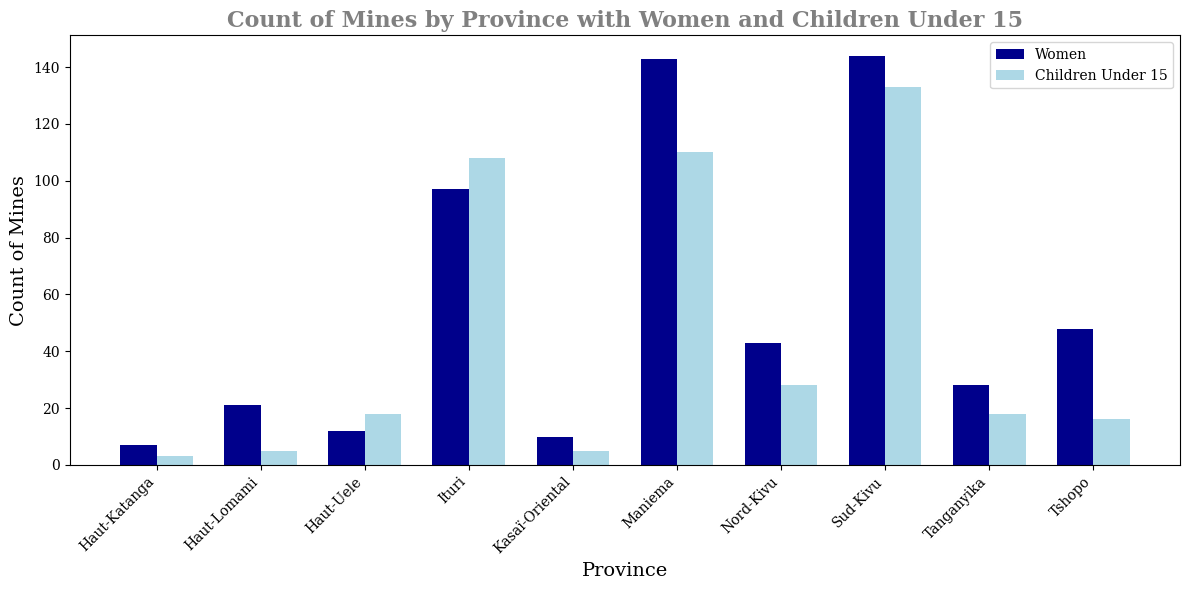

In [25]:
# Let's start by counting the number of women and children under 15 working in mines across provinces and in specific minerals
# Filter relevant columns
relevant_data = unique_mines_visited[['province', 'childunder15', 'women']].dropna()

# Group by province and calculate the sum of binary columns
grouped_data = relevant_data.groupby('province').sum()

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))

# Set bar positions
x = np.arange(len(grouped_data.index))  # Number of unique provinces
bar_width = 0.35

# Plot bars for women and children under 15
ax.bar(x - bar_width / 2, grouped_data['women'], bar_width, label='Women', color="darkblue")
ax.bar(x + bar_width / 2, grouped_data['childunder15'], bar_width, label='Children Under 15', color="lightblue")

# Add labels, title, and legend
ax.set_xlabel('Province', fontsize=14)
ax.set_ylabel('Count of Mines', fontsize=14)
ax.set_title('Count of Mines by Province with Women and Children Under 15', fontsize=16, fontweight="bold", color="gray")
ax.set_xticks(x)
ax.set_xticklabels(grouped_data.index, rotation=45, ha='right')
ax.legend()

# Display the plot
plt.tight_layout()
plt.show()

In [26]:
# How many female artisanal miners are involved in mining each of the different minerals?
women = unique_mines_visited[unique_mines_visited['women'] == 1]
women_mineral = women['grouped_minerals'].value_counts()
print(women_mineral)

# Which territory has the highest percentage of mines with female miners?
women_sidkivu_maniema = women[women['province'].isin(['Sud-Kivu', 'Maniema'])]
women_territory = women_sidkivu_maniema['territoire'].value_counts()
print(women_territory)

women_interference = women.groupby('grouped_minerals')['interference'].sum()
print(women_interference)


grouped_minerals
Gold           332
Cassiterite    183
Coltan          22
Diamond         16
Wolframite       3
Other            1
Name: count, dtype: int64
territoire
Shabunda     68
Pangi        48
Punia        33
Mwenga       31
Lubutu       30
Walungu      17
Kailo        16
Kalehe       15
Kasongo      14
Kabambare     5
Fizi          5
Kabare        4
Idjwi         1
Name: count, dtype: int64
grouped_minerals
Cassiterite     45.0
Coltan          11.0
Diamond          0.0
Gold           170.0
Other            0.0
Wolframite       0.0
Name: interference, dtype: float64


In [27]:
# Women are primarily working in gold mines, particularly in South Kivu (Shabunda territory) and Maniema (Pangi territory) provinces.
# Are women exposed to pillaging?
women_pillaging = women['pillaging_armed_group1'].value_counts()
print(women_pillaging)

filtered_df = unique_mines_visited[(unique_mines_visited['pillaging_armed_group1'] == 1) & (unique_mines_visited['women'] == 1)]
print(filtered_df.groupby('province')['pillaging_armed_group1'].sum())

pillaging_armed_group1
0.0    291
1.0     10
Name: count, dtype: int64
province
Ituri         2.0
Nord-Kivu     1.0
Sud-Kivu      5.0
Tanganyika    1.0
Tshopo        1.0
Name: pillaging_armed_group1, dtype: float64


In [28]:
# Are women working at mines with forced labor?
forced_labor = unique_mines_visited.groupby('province')['forced_labour_armed_group1'].sum()
print(forced_labor)
forced_labor_women = women.groupby('province')['forced_labour_armed_group1'].sum()
print(forced_labor_women) 

province
Bas-Uele           0.0
Haut-Katanga       0.0
Haut-Lomami        0.0
Haut-Uele          0.0
Ituri              3.0
Kasaï-Oriental     0.0
Lualaba            0.0
Maniema            1.0
Nord-Kivu         26.0
Sud-Kivu          23.0
Tanganyika        24.0
Tshopo            17.0
Name: forced_labour_armed_group1, dtype: float64
province
Haut-Katanga       0.0
Haut-Lomami        0.0
Haut-Uele          0.0
Ituri              2.0
Kasaï-Oriental     0.0
Maniema            1.0
Nord-Kivu          1.0
Sud-Kivu           4.0
Tanganyika         8.0
Tshopo            15.0
Name: forced_labour_armed_group1, dtype: float64


In [29]:
# How many children under 15 are involved in mining each of the different minerals?
child = unique_mines_visited[unique_mines_visited['childunder15'] == 1]
child_mineral = child['grouped_minerals'].value_counts()
print(child_mineral)

# Which territory has the highest percentage of mines with female miners? Include proportion of mines with interference.
child_sidkivu_maniema = child[child['province'].isin(['Sud-Kivu', 'Maniema'])]
child_territory = child_sidkivu_maniema['territoire'].value_counts()
print(child_territory)

child_interference = child.groupby('grouped_minerals')['interference'].sum()
print(child_interference)

grouped_minerals
Gold           331
Cassiterite     96
Coltan          12
Diamond          5
Wolframite       1
Name: count, dtype: int64
territoire
Shabunda     62
Punia        29
Pangi        27
Fizi         22
Lubutu       21
Mwenga       19
Kasongo      15
Kailo        15
Walungu      14
Kalehe       11
Kabare        5
Kabambare     3
Name: count, dtype: int64
grouped_minerals
Cassiterite     25.0
Coltan           9.0
Diamond          0.0
Gold           179.0
Wolframite       0.0
Name: interference, dtype: float64


In [31]:
# If there is armed group interference at a mining site, there may also be an observation of an illegal activity by IPIS or another organization. Let's see if there is any pillaging, forced labor, or monopoly activity.
# There can be multiple armed groups so we start with combining them accordingly
pillaging_columns = ['pillaging_armed_group1', 'pillaging_armed_group2', 'pillaging_armed_group3']
monopoly_columns = ['monopoly_armed_group1', 'monopoly_armed_group2', 'monopoly_armed_group3']
forced_labour_columns = ['forced_labour_armed_group1', 'forced_labour_armed_group2', 'forced_labour_armed_group3']

# Replace NaN with 0 for the binary columns
working_conditions_data = unique_mines_visited[['province', 'workers_numb'] + pillaging_columns + monopoly_columns + forced_labour_columns].fillna(0)

# Create consolidated columns for each working condition and take max (or 1 indicating 'yes') value for each row
working_conditions_data['pillaging'] = working_conditions_data[pillaging_columns].max(axis=1)
working_conditions_data['monopoly'] = working_conditions_data[monopoly_columns].max(axis=1)
working_conditions_data['forced_labour'] = working_conditions_data[forced_labour_columns].max(axis=1)

# Group by province and calculate the sum for each condition and workers
grouped_conditions = working_conditions_data.groupby('province').agg({
    'workers_numb': 'sum',
    'pillaging': 'sum',
    'monopoly': 'sum',
    'forced_labour': 'sum',
}).reset_index()

# Display the summarized data
print(grouped_conditions)

          province  workers_numb  pillaging  monopoly  forced_labour
0         Bas-Uele        3404.0        0.0       0.0            0.0
1     Haut-Katanga       19510.0        0.0       0.0            0.0
2      Haut-Lomami       10259.0        0.0       0.0            0.0
3        Haut-Uele        4265.0        0.0       0.0            0.0
4            Ituri       77654.0       56.0      41.0            3.0
5   Kasaï-Oriental        2877.0        0.0       0.0            0.0
6          Lualaba       47346.0        0.0       0.0            0.0
7          Maniema       67422.0        3.0       9.0            1.0
8        Nord-Kivu       76402.0       82.0     113.0           28.0
9         Sud-Kivu      127418.0       45.0      12.0           28.0
10      Tanganyika       22878.0        5.0       1.0           24.0
11          Tshopo        8056.0        3.0      47.0           17.0


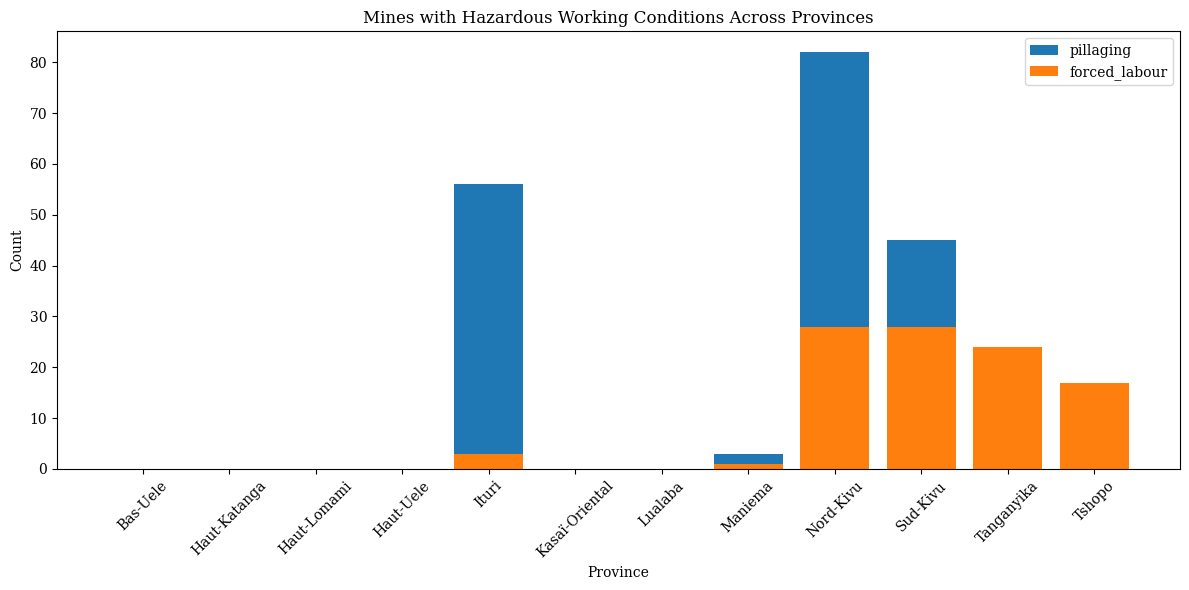

In [32]:
# Plot the data
conditions = ['pillaging', 'forced_labour']
x = grouped_conditions['province']

fig, ax = plt.subplots(figsize=(12, 6))
for condition in conditions:
    ax.bar(x, grouped_conditions[condition], label=condition)

ax.set_xlabel('Province')
ax.set_ylabel('Count')
ax.set_title('Mines with Hazardous Working Conditions Across Provinces')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
# Initialize dictionaries to store counts
pillaging_counts = pd.Series(dtype=int)
forced_labor_counts = pd.Series(dtype=int)

# Define mappings of activity to type columns
activity_columns = {
    'pillaging': ['pillaging_armed_group1', 'pillaging_armed_group2', 'pillaging_armed_group3'],
    'forced_labor': ['forced_labour_armed_group1', 'forced_labour_armed_group2', 'forced_labour_armed_group3'],
}

type_columns = ['armed_group1', 'armed_group2', 'armed_group3']

# Iterate through the activity columns and count the corresponding types
for activity, columns in activity_columns.items():
    for col_activity, col_type in zip(columns, type_columns):
        # Filter rows where the activity column is 1 and count the corresponding types
        counts = unique_mines_visited.loc[unique_mines_visited[col_activity] == 1, col_type].value_counts()
        
        # Aggregate counts into the respective series
        if activity == 'pillaging':
            pillaging_counts = pillaging_counts.add(counts, fill_value=0)
        elif activity == 'forced_labor':
            forced_labor_counts = forced_labor_counts.add(counts, fill_value=0)

# Combine the counts into a DataFrame
armed_group_summary = pd.DataFrame({
    'pillaging_count': pillaging_counts,
    'forced_labor_count': forced_labor_counts
}).fillna(0)  # Fill NaN with 0 for groups involved in only one activity

# Add a total column for overall occurrences
armed_group_summary['total_count'] = armed_group_summary['pillaging_count'] + armed_group_summary['forced_labor_count']

# Sort by total occurrences
armed_group_summary = armed_group_summary.sort_values('total_count', ascending=False)

# Display the summary
print("Armed Group Summary:")
print(armed_group_summary)


Armed Group Summary:
                                        pillaging_count  forced_labor_count  \
FARDC                                              17.0                66.0   
NDC-Rénové                                         42.0                 7.0   
Maï-Maï Simba (ex-Morgan - Mangaribi)              30.0                 0.0   
Maï-Maï Simba (ex-Morgan - Manu)                   27.0                 0.0   
Raïa Mutomboki                                     20.0                 3.0   
NDC                                                16.0                 0.0   
FRPI                                               14.0                 1.0   
ADF                                                12.0                 0.0   
Maï-Maï Yakutumba                                   5.0                 5.0   
Maï-Maï Simba                                       5.0                 4.0   
Ngomino                                             4.0                 4.0   
Maï-Maï Apa Na Pale            

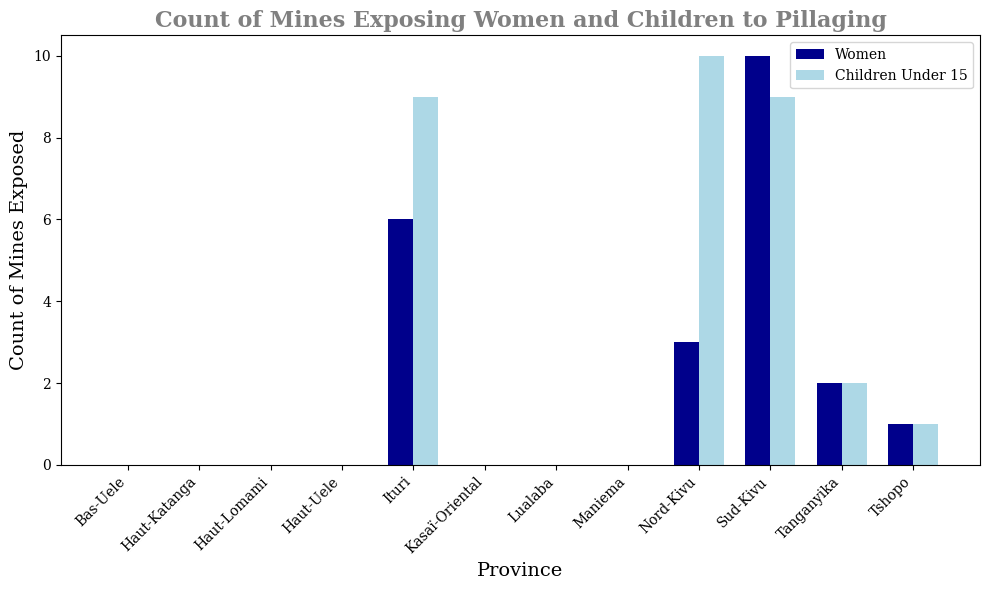

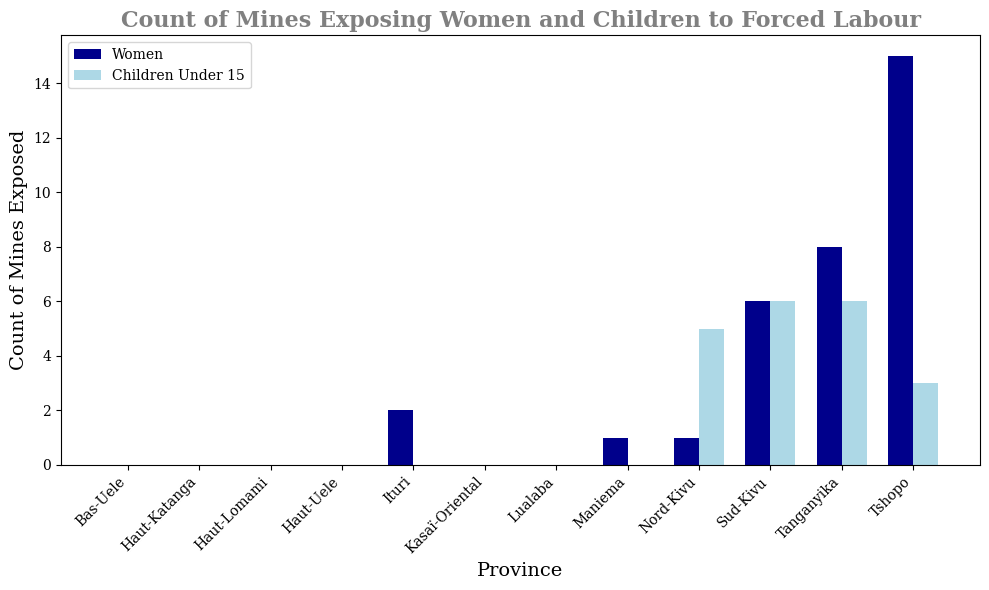

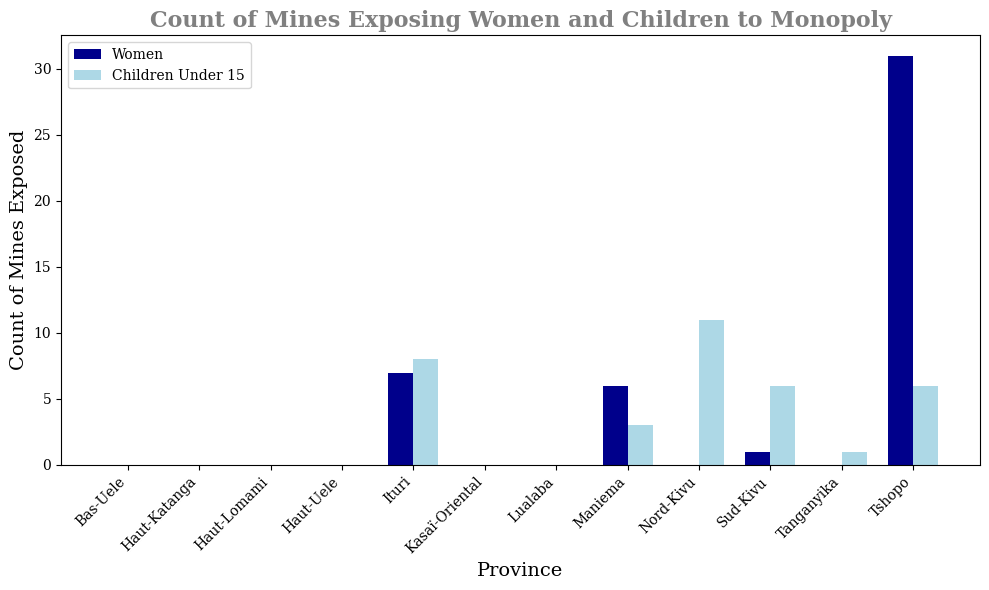

In [34]:
# Define the conditions of interest
conditions = ['pillaging', 'forced_labour', 'monopoly']

# Consolidate columns for each condition (armed_group1, 2, 3)
for condition in conditions:
    condition_columns = [f"{condition}_armed_group{i}" for i in range(1, 4)]  # armed_group1, 2, 3
    unique_mines_visited[condition] = unique_mines_visited[condition_columns].max(axis=1, skipna=True)  # Check for any '1'

# Filter relevant columns
relevant_columns = ['province', 'women', 'childunder15'] + conditions
filtered_data = unique_mines_visited[relevant_columns].fillna(0)

# Create binary indicators for whether women or children are exposed to each condition
for condition in conditions:
    filtered_data[f'women_{condition}'] = filtered_data['women'] * filtered_data[condition]
    filtered_data[f'children_{condition}'] = filtered_data['childunder15'] * filtered_data[condition]

# Group by province and calculate the proportion of mines with women or children exposed
grouped_data = filtered_data.groupby('province').sum()

# Loop through conditions and plot clustered bar charts
for condition in conditions:
    plt.figure(figsize=(10, 6))
    
    # Extract data for the condition
    women_proportion = grouped_data[f'women_{condition}'] 
    children_proportion = grouped_data[f'children_{condition}']
    
    x = np.arange(len(grouped_data.index))  # X positions for provinces
    bar_width = 0.35
    
    # Plot the clustered bar chart
    plt.bar(x - bar_width / 2, women_proportion, width=bar_width, label='Women', color='darkblue')
    plt.bar(x + bar_width / 2, children_proportion, width=bar_width, label='Children Under 15', color='lightblue')

    # Add labels, title, and legend
    plt.xlabel('Province', fontsize=14)
    plt.ylabel('Count of Mines Exposed', fontsize=14)
    plt.title(f'Count of Mines Exposing Women and Children to {condition.title().replace("_", " ")}', fontsize=16, fontweight="bold", color="gray")
    plt.xticks(x, grouped_data.index, rotation=45, ha='right')
    plt.legend()

    
    # Show the plot
    plt.tight_layout()
    plt.show()


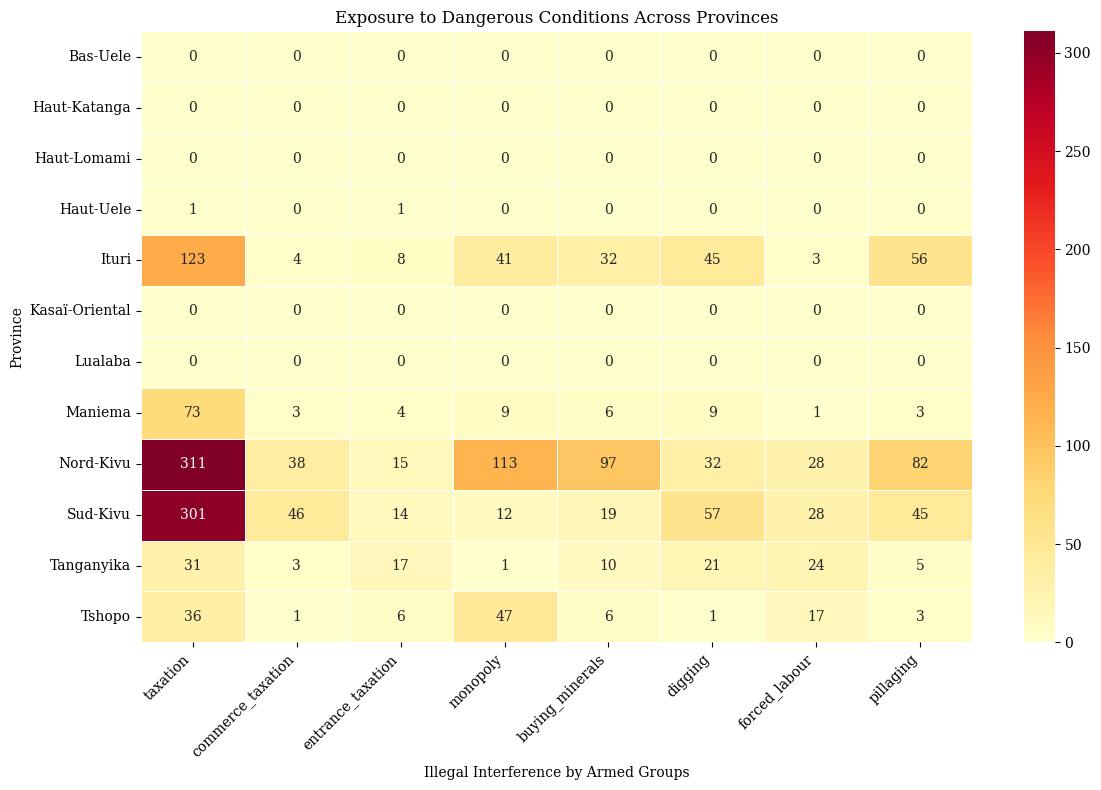

In [35]:
# Define dangerous conditions and their respective columns for armed groups
conditions = ['taxation', 'commerce_taxation', 'entrance_taxation', 'monopoly', 
              'buying_minerals', 'digging', 'forced_labour', 'pillaging']

# Combine columns across armed groups for each condition
for condition in conditions:
    condition_columns = [f"{condition}_armed_group{i}" for i in range(1, 4)]  # armed_group1, 2, 3
    unique_mines_visited[condition] = unique_mines_visited[condition_columns].max(axis=1, skipna=True)  # Check for any '1'

# Filter relevant columns for analysis
relevant_columns = ['province'] + conditions
condition_data = unique_mines_visited[relevant_columns].fillna(0)

# Group by province and sum the occurrences for each condition
grouped_conditions = condition_data.groupby('province').sum()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(grouped_conditions, annot=True, cmap='YlOrRd', fmt='g', linewidths=0.5)

# Add labels and title
plt.title('Exposure to Dangerous Conditions Across Provinces')
plt.xlabel('Illegal Interference by Armed Groups')
plt.ylabel('Province')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

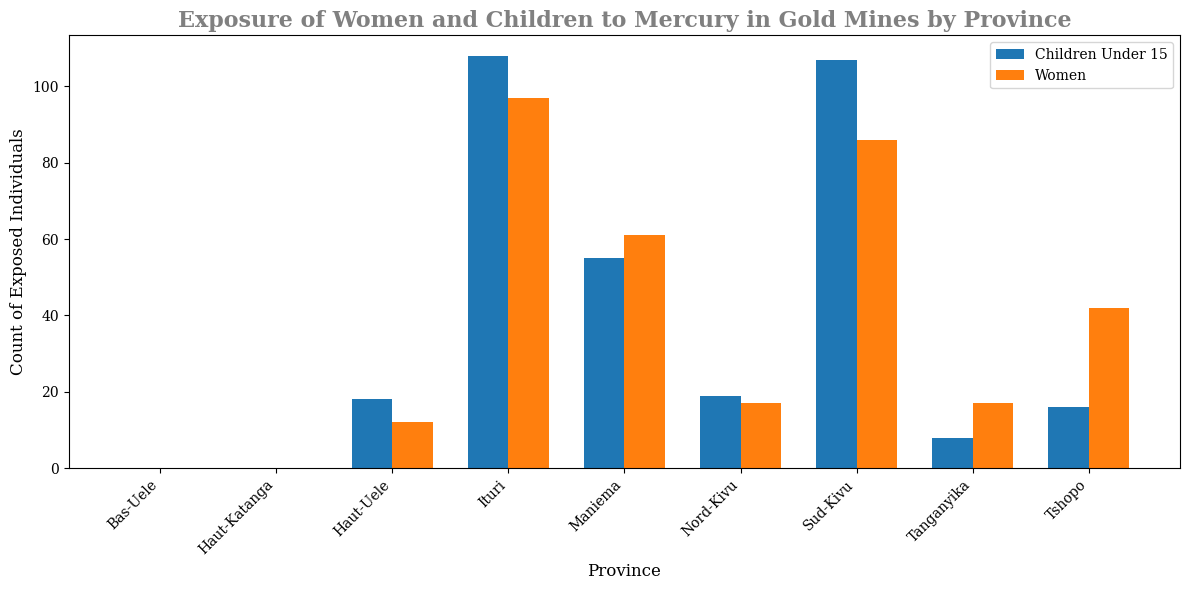

In [47]:
# Ensure numeric conversion for relevant columns
unique_mines_visited['mercury'] = pd.to_numeric(unique_mines_visited['mercury'], errors='coerce').fillna(0).astype(int)
unique_mines_visited['women'] = pd.to_numeric(unique_mines_visited['women'], errors='coerce').fillna(0).astype(int)
unique_mines_visited['childunder15'] = pd.to_numeric(unique_mines_visited['childunder15'], errors='coerce').fillna(0).astype(int)

# Filter for gold mines ('Or')
gold_mines = unique_mines_visited[unique_mines_visited['grouped_minerals'] == 'Gold']

# Identify gold mines exposing women and/or children to mercury
gold_mines['women_or_children_mercury'] = (gold_mines['mercury'] == 1) & ((gold_mines['women'] == 1) | (gold_mines['childunder15'] == 1))

# Group by province and calculate the total count of women and children exposed
grouped_exposure = gold_mines.groupby('province').agg(
    women=('women', 'sum'),
    childunder15=('childunder15', 'sum')
).reset_index()

# Calculate the percentage of exposure (exposed women or children to mercury)
grouped_exposure['percentage_exposed'] = gold_mines.groupby('province').apply(
    lambda x: 100 * x['women_or_children_mercury'].sum() / len(x)
).values

# Now, let's combine both bars (children and women) into one figure
x = np.arange(len(grouped_exposure['province']))  # Position for each province
bar_width = 0.35  # Width for each bar

# Create the plot with one figure
fig, ax = plt.subplots(figsize=(12, 6))

# Bars for children under 15
ax.bar(x - bar_width / 2, grouped_exposure['childunder15'], bar_width, label='Children Under 15')

# Bars for women
ax.bar(x + bar_width / 2, grouped_exposure['women'], bar_width, label='Women')

# Add labels, title, and formatting
ax.set_title('Exposure of Women and Children to Mercury in Gold Mines by Province', fontsize=16, fontweight="bold", color="gray")
ax.set_xlabel('Province', fontsize=12)
ax.set_ylabel('Count of Exposed Individuals', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(grouped_exposure['province'], rotation=45, ha='right')

# Display legend
ax.legend()

# Ensure the plot layout is tight
plt.tight_layout()

# Show the plot
plt.show()


In [52]:
# Check for 'prostitution' in the 'womenwork' column
unique_mines_visited['mentions_prostitution'] = unique_mines_visited['womenwork'].str.contains('prostitution', case=False, na=False).astype(int)

# Group by province and grouped_minerals, and calculate percentages
prostitution_mention = (
    unique_mines_visited.groupby(['province', 'grouped_minerals'])
    .apply(lambda x: 100 * x['mentions_prostitution'].sum() / len(x))
    .reset_index(name='percentage_prostitution')
)

print(prostitution_mention)

          province grouped_minerals  percentage_prostitution
0         Bas-Uele             Gold                 0.000000
1     Haut-Katanga      Cassiterite                 0.000000
2     Haut-Katanga           Cobalt                 0.000000
3     Haut-Katanga           Coltan                 0.000000
4     Haut-Katanga           Copper                 0.000000
5     Haut-Katanga             Gold                 0.000000
6      Haut-Lomami      Cassiterite                 1.351351
7      Haut-Lomami           Coltan                 0.000000
8        Haut-Uele             Gold                 0.000000
9            Ituri           Coltan                 0.000000
10           Ituri             Gold                 1.318681
11           Ituri            Other                 0.000000
12  Kasaï-Oriental          Diamond                 0.000000
13         Lualaba      Cassiterite                 0.000000
14         Lualaba           Cobalt                 0.000000
15         Lualaba      

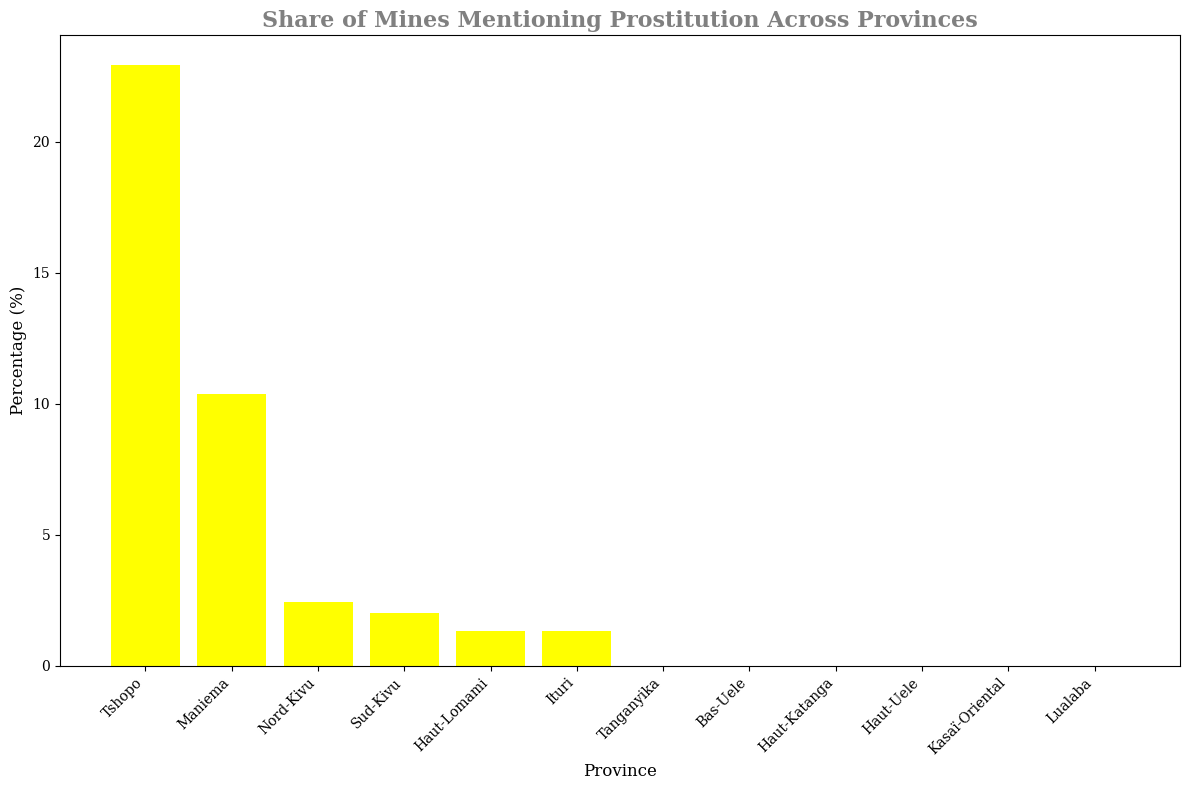

In [53]:
# Sort prostitution data for visualization
prostitution_data = prostitution_mention.sort_values(by='percentage_prostitution', ascending=False)

# Plot the bar chart
plt.figure(figsize=(12, 8))
plt.bar(prostitution_data['province'], prostitution_data['percentage_prostitution'], color='yellow')

# Add labels and title
plt.title('Share of Mines Mentioning Prostitution Across Provinces', fontsize=16, fontweight="bold", color="gray")
plt.xlabel('Province', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Ensure the plot layout is tight
plt.tight_layout()

# Show the plot
plt.show()

# Geospatial Data Analysis
Using the World Database on Protected Areas, we can use the polygon data of protected areas in the DRC and overlay them on the mining sites polygon data to explore which areas intersect and may therefore be negatively impacting or destroying wildlife and their surrounding ecosystems. 

In [54]:
# Read the protected areas data that we'll be using to overlay on the mining sites polygon data to explore whether mining activities are distrubing any protected areas
# We'll be reading in three separate shapefiles (which were split due to large size) from the World Database on Protected Areas (https://www.protectedplanet.net/country/COD)
drc_protected_areas_0 = gpd.read_file("C:\\Users\\sylwi\\OneDrive\\Documents\\GitHub\\DRC_Artisinal_Mining\\WDPA\\WDPA_WDOECM_May2024_Public_COD_shp_0\\WDPA_WDOECM_May2024_Public_COD_shp-polygons.shp")
drc_protected_areas_1 = gpd.read_file("C:\\Users\\sylwi\\OneDrive\\Documents\\GitHub\\DRC_Artisinal_Mining\\WDPA\\WDPA_WDOECM_May2024_Public_COD_shp_1\\WDPA_WDOECM_May2024_Public_COD_shp-polygons.shp")
drc_protected_areas_2 = gpd.read_file("C:\\Users\\sylwi\\OneDrive\\Documents\\GitHub\\DRC_Artisinal_Mining\\WDPA\\WDPA_WDOECM_May2024_Public_COD_shp_2\\WDPA_WDOECM_May2024_Public_COD_shp-polygons.shp")

In [55]:
# Combining all three shapefiles
drc_protected_areas_combined = pd.concat([drc_protected_areas_0, drc_protected_areas_1, drc_protected_areas_2], ignore_index=True)

# Saved the combined shapefile
drc_protected_areas_combined.to_file('drc_combined_shp_polygons.shp')

In [56]:
# Print the first few rows and Coordinate Reference System (CRS)
print(drc_protected_areas_combined.head())
print(drc_protected_areas_combined.crs)

   WDPAID WDPA_PID PA_DEF          NAME     ORIG_NAME          DESIG  \
0  1079.0     1079      1        Upemba        Upemba  Parc National   
1  1080.0     1080      1         Maiko         Maiko  Parc National   
2  1082.0     1082      1  Kahuzi-Biega  Kahuzi-Biega  Parc National   
3  1083.0     1083      1       Garamba       Garamba  Parc National   
4  1084.0     1084      1    Kundelungu    Kundelungu  Parc National   

       DESIG_ENG DESIG_TYPE IUCN_CAT        INT_CRIT  ...  \
0  National Park   National       II  Not Applicable  ...   
1  National Park   National       II  Not Applicable  ...   
2  National Park   National       II  Not Applicable  ...   
3  National Park   National       II  Not Applicable  ...   
4  National Park   National       II  Not Applicable  ...   

                                           MANG_AUTH     MANG_PLAN  \
0  Institut Congolais pour la Conservation de la ...  Not Reported   
1  Institut Congolais pour la Conservation de la ...  Not Re

In [57]:
# To ensure we can do distance-based calculations, we will convert them to a projected CRS: the local UTM zone 35, which is identified by EPSG:32735 (https://epsg.io/32735)
drc_mining_sites_utm = drc_mining_sites.to_crs("EPSG:32735")
drc_protected_areas_combined_utm = drc_protected_areas_combined.to_crs("EPSG:32735")

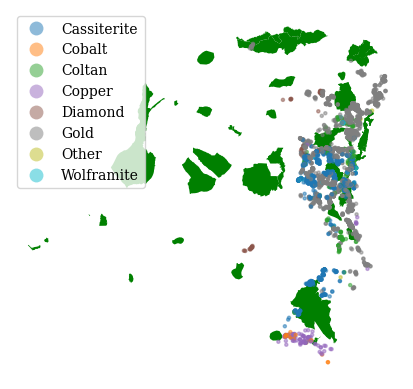

In [58]:
# Both the mining sites and protected areas datasets are in the same CRS: 4326. We can proceed with plotting both to visualize the overlay
ax = drc_protected_areas_combined_utm.plot(color='green')
drc_mining_sites_utm.plot(ax=ax, markersize=5, column='grouped_minerals', alpha=0.5, legend=True)
ax.set_axis_off()
plt.show()

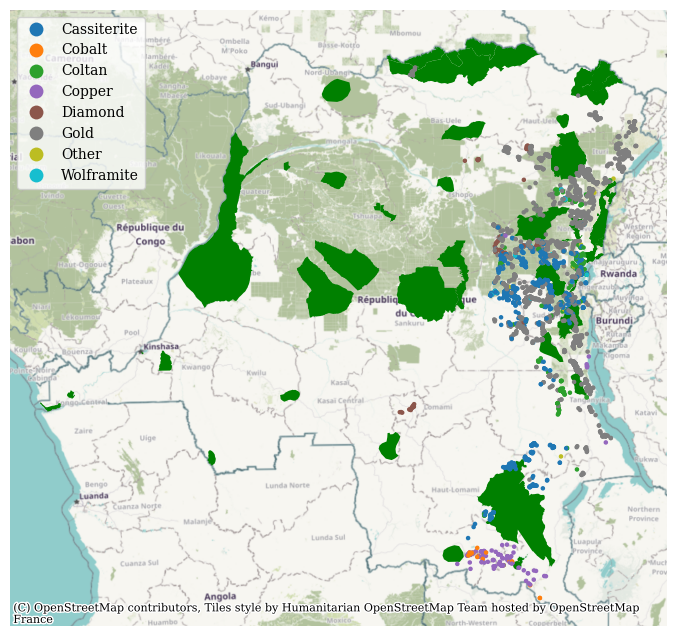

In [320]:
import contextily as cx

# For better visualization, let's replot using a basemap with the same CRS and making some visual adjustments
fig, ax = plt.subplots(figsize=(12, 8)) 
drc_protected_areas_combined_utm.plot(color='green', ax=ax)
drc_mining_sites_utm.plot(ax=ax, markersize=5, column='grouped_minerals', legend=True)
ax.set_axis_off()
cx.add_basemap(ax, crs='epsg:32735')
plt.show()

In [59]:
# Now, let's consider whether these mining sites are nearby and impacting any local cities.
# Import the Point geometry
from shapely.geometry import Point

# Construct a point object for Kolwezi city using UTM coordinates
kolwezi = Point(332323.09602508, 8815133.3504124)

# Create a buffer of 50km around Kolwezi, note CRS is in meters
kolwezi_buffer = kolwezi.buffer(50000)

# Confirm that the buffer is a polygon
print(type(kolwezi_buffer))

# Check how many mining sites are located within the buffer
mask = drc_mining_sites_utm.within(kolwezi_buffer)
print(mask.sum(), "mining sites are located within the Kolwezi buffer.")

# Calculate the area of national park within the buffer in km2
protected_area_intersection = drc_protected_areas_combined_utm.intersection(kolwezi_buffer).area.sum() / (1000**2)
print(protected_area_intersection, "km2 of protected area are contained within 50 km of Kolwezi, as captured through the World Database on Protected Areas (WDPA).")

<class 'shapely.geometry.polygon.Polygon'>
61 mining sites are located within the Kolwezi buffer.
926.2711275267936 km2 of protected area are contained within 50 km of Kolwezi, as captured through the World Database on Protected Areas (WDPA).


In [60]:
# Determine in which protected area a mining site is located
sites_within_protected_areas = gpd.sjoin(drc_mining_sites_utm, drc_protected_areas_combined_utm, op='within', how='inner')

# Drop duplicate mines
unique_intersections = sites_within_protected_areas.drop_duplicates(subset="pcode")
# Count the number of intersections
count = len(unique_intersections)

print("Number of intersections:", count)

# Group by province and sum the occurrences for each condition
grouped_conditions = condition_data.groupby('province').sum()

# 117 unique intersections were found. Which minerals are typically mined in protected areas?
print(unique_intersections['grouped_minerals'].value_counts())

# Assuming that interfering armed groups also engaged in poor enviornmental practices, how many of these intersections happen in mines with interference?
print(unique_intersections['interference'].sum())

# And finally, let's look at the locations themselves. Which provinces are the intersections most prevalent?
print(unique_intersections['province'].value_counts())
# Let's look a level deeper at territories
print(unique_intersections['territoire'].value_counts())


Number of intersections: 117
grouped_minerals
Gold           69
Cassiterite    44
Coltan          2
Copper          2
Name: count, dtype: int64
49.0
province
Sud-Kivu        46
Nord-Kivu       18
Haut-Lomami     18
Bas-Uele        12
Maniema          8
Ituri            7
Tanganyika       3
Tshopo           2
Haut-Katanga     2
Haut-Uele        1
Name: count, dtype: int64
territoire
Mwenga           32
Malemba-Nkulu    16
Lubero           14
Bondo            12
Kabambare         8
Shabunda          7
Mambasa           7
Kalehe            4
Walikale          4
Kalemie           3
Kabare            2
Bafwasende        2
Bukama            2
Kambove           2
Fizi              1
Dungu             1
Name: count, dtype: int64


<Figure size 1000x600 with 0 Axes>

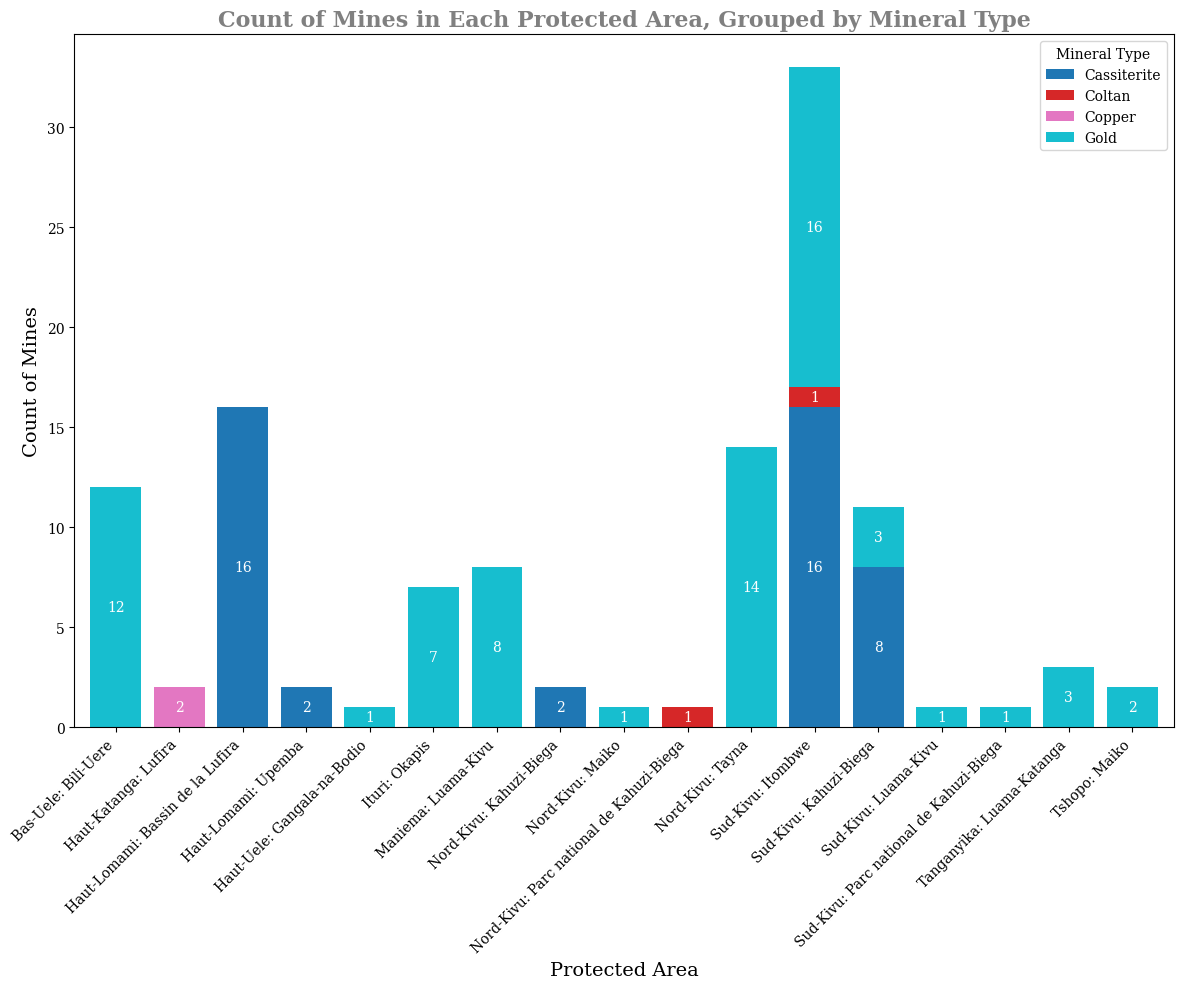

In [61]:
# Combine 'province' and 'ORIG_NAME' to create a more detailed label for x-axis
unique_intersections['area_with_province'] = unique_intersections['province'] + ': ' + unique_intersections['ORIG_NAME']

# Group by 'ORIG_NAME' (protected area) and 'grouped_minerals' (mineral type)
mines_per_area = unique_intersections.groupby(['area_with_province', 'grouped_minerals']).size().reset_index(name='count')

# Pivot the data to get a count of minerals for each protected area
mines_per_area_pivot = mines_per_area.pivot_table(index='area_with_province', columns='grouped_minerals', values='count', fill_value=0)

# Plot the stacked bar chart
plt.figure(figsize=(10, 6))
mines_per_area_pivot.plot(kind='bar', stacked=True, figsize=(12, 10), width=0.8, cmap="tab10")

# Adding labels and title
plt.title('Count of Mines in Each Protected Area, Grouped by Mineral Type', fontsize=16, fontweight="bold", color="gray")
plt.xlabel('Protected Area', fontsize=14)
plt.ylabel('Count of Mines', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Mineral Type')

# Add counts inside the stacked bars using plt.text()
for bar_index in range(len(mines_per_area_pivot)):
    cumulative_height = [0] * len(mines_per_area_pivot)  # Keep track of cumulative heights for each stack
    for col_index, col in enumerate(mines_per_area_pivot.columns):
        value = mines_per_area_pivot.iloc[bar_index, col_index]
        if value > 0:  # Only label non-zero values
            x_position = bar_index  # Bar's x-coordinate
            y_position = cumulative_height[bar_index] + value / 2  # Center of the segment
            plt.text(
                x_position, 
                y_position, 
                str(int(value)), 
                ha='center', 
                va='center', 
                color='white', 
                fontsize=10
            )
            cumulative_height[bar_index] += value  # Update the cumulative height

# Show the plot
plt.tight_layout()
plt.show()

In [62]:
# A majority of the mining sites exist within Itombwe Nature reserve, home to the critically endangered eastern lowland gorilla.
# Extract the single polygon for the Itombwe Nature Reserve
itombwe = drc_protected_areas_combined_utm[drc_protected_areas_combined_utm['ORIG_NAME'] == "Itombwe"].geometry.squeeze()

# Take a subset of the mining sites located within Itombwe using the within() method on the geometry column of the mining_sites GeoDataFrame to check if each site is within Itombwe
sites_itombwe = drc_mining_sites_utm[drc_mining_sites_utm.geometry.within(itombwe)]
print(sites_itombwe)

       vid   cid    id                      source  \
42      43    43    43  IPIS - Ministère des Mines   
85      86    86    86  IPIS - Ministère des Mines   
106    107   107   107  IPIS - Ministère des Mines   
183    184   184   184  IPIS - Ministère des Mines   
1501  1502  1348  1348  IPIS - Ministère des Mines   
1724  1725   337   337                         BGR   
2131  2132  1597  1597  IPIS - Ministère des Mines   
2152  2153  1616  1616  IPIS - Ministère des Mines   
2155  2156  1619  1619  IPIS - Ministère des Mines   
2156  2157  1620  1620  IPIS - Ministère des Mines   
2158  2159  1622  1622  IPIS - Ministère des Mines   
2159  2160  1623  1623  IPIS - Ministère des Mines   
2161  2162  1625  1625  IPIS - Ministère des Mines   
2162  2163  1626  1626  IPIS - Ministère des Mines   
2165  2166  1629  1629  IPIS - Ministère des Mines   
2172  2173  1636  1636  IPIS - Ministère des Mines   
2173  2174  1637  1637  IPIS - Ministère des Mines   
2179  2180  1643  1643  IPIS

In [63]:
# What is the distance from the first mining site in the dataset to the closest protected national park
# Get the geometry of the first row
single_mine = drc_mining_sites_utm.geometry[0]

# Calculate the distance from each national park to this mine
dist = drc_protected_areas_combined_utm.distance(single_mine)

# The index of the minimal distance
idx = dist.idxmin()

# Access the name of the corresponding national park
closest_protected_area = drc_protected_areas_combined_utm.loc[idx, 'ORIG_NAME']
print(closest_protected_area)

Maiko


In [64]:
# Now we know how to get the closest national park for a single point, let's do this for all points using a custom function
# Define a function that returns the closest protected area
def closest_protected_area(geom, drc_protected_areas_combined_utm):
    dist = drc_protected_areas_combined_utm.distance(geom)
    idx = dist.idxmin()
    closest_area = drc_protected_areas_combined_utm.loc[idx, 'ORIG_NAME']
    return closest_area

# Call the function on single_mine, testing whether it returns the same result as above
print(closest_protected_area(single_mine, drc_protected_areas_combined_utm))

# Apply the function to all mining sites and assign the result to a column called 'closest_area'
drc_mining_sites_utm['closest_area'] = drc_mining_sites_utm.geometry.apply(closest_protected_area, drc_protected_areas_combined_utm=drc_protected_areas_combined_utm)
print(drc_mining_sites_utm.head())

Maiko
   vid  cid  id                      source      project         pcode  \
0    1    1   1  IPIS - Ministère des Mines  IPIS - 2009  codmine00191   
1    2    2   2  IPIS - Ministère des Mines  IPIS - 2009  codmine00192   
5    6    6   6  IPIS - Ministère des Mines  IPIS - 2009  codmine00286   
6    7    7   7  IPIS - Ministère des Mines  IPIS - 2009  codmine00288   
7    8    8   8  IPIS - Ministère des Mines  IPIS - 2009  codmine00290   

      name visit_date  visit_onsite visit_onsite_novisitreason  ...  \
0     Eohe 2009-01-01             1                       None  ...   
1     Eita 2009-01-01             1                       None  ...   
5  Kasongo 2009-01-01             1                       None  ...   
6  Mununze 2009-01-01             1                       None  ...   
7   Kiboto 2009-01-01             1                       None  ...   

   traceability  qualification childunder15 childunder15work women womenwork  \
0          None           None          Na